# Extratos Bancários — Análise Aprofundada (ago/2025–jun/2026)

Notebook focado nos extratos bancários do Condomínio

**Fonte**: `exports/csv/extratos.csv` — lançamentos ago/2025–jun/2026

> Para análise das Prestações de Contas (2022–2023) ver `analise.ipynb`

> ⚠️ **Gap de dados**: ago/2023–ago/2025 não coberto (PDFs fora do escopo)

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 5)})
sns.set_theme(style="whitegrid", palette="tab10")

CSV_DIR     = Path("../exports/csv")
EXTRATO_DIR = Path("../exports/hojas/extrato")


def _br(s) -> float | None:
    """Converte string BR (1.234,56) ou número para float."""
    if isinstance(s, (int, float)):
        return None if pd.isna(s) else float(s)
    s = str(s).strip()
    if s in ("-", "", "nan"):
        return None
    try:
        return float(re.sub(r"\s", "", s).replace(".", "").replace(",", "."))
    except ValueError:
        return None

## 1. Carregar dados

In [2]:
import lxml.html

df_ext   = pd.read_csv(CSV_DIR / "extratos.csv", parse_dates=["data"])
df_prest = pd.read_csv(CSV_DIR / "prestacoes.csv")  # usado apenas na seção Síndico (comparação)

print(f"Extratos   : {len(df_ext):,} registros  |  {df_ext['data'].min().date()} → {df_ext['data'].max().date()}")
print(f"Prestações : {len(df_prest):,} registros  (carregado apenas para comparação do síndico)")
print(f"\nColunas: {list(df_ext.columns)}")

Extratos   : 6,215 registros  |  2025-08-01 → 2026-06-30
Prestações : 2,389 registros  (carregado apenas para comparação do síndico)

Colunas: ['mes_ano', 'data', 'subconta', 'historico', 'complemento', 'debito', 'credito', 'saldo', 'saldo_anterior']


## 1.5 Validação — conferência com totais originais

Cada arquivo fonte contém uma tabela de totalizações. Aqui comparamos esses valores contra as somas do CSV para garantir que nenhuma linha foi perdida ou duplicada.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# EXTRATO — re-lê a tabela de totalizações embutida no final de cada XLS
# ══════════════════════════════════════════════════════════════════════════════
orig_ext = []
for fp in sorted(EXTRATO_DIR.glob("*.xls")):
    yy, mm = fp.stem.split("_")
    mes_ano = f"20{yy}-{mm.zfill(2)}"
    with open(fp, "r", encoding="utf-8", errors="ignore") as fh:
        tree = lxml.html.fromstring(fh.read())
    for row in tree.xpath("//tr[@class='dados']"):
        texts = [c.text_content().strip() for c in row.xpath(".//td")]
        if len(texts) >= 5 and texts[0] not in ("Total", ""):
            orig_ext.append({
                "mes_ano":        mes_ano,
                "subconta":       texts[0],
                "saldo_ant_orig": _br(texts[1]),
                "debitos_orig":   _br(texts[2]),
                "creditos_orig":  _br(texts[3]),
                "total_orig":     _br(texts[4]),
            })

df_orig_ext = pd.DataFrame(orig_ext)

df_calc_ext = (
    df_ext.groupby(["mes_ano", "subconta"])
    .agg(
        saldo_ant_csv=("saldo_anterior", "first"),
        debitos_csv  =("debito",  lambda x: x.fillna(0).sum()),
        creditos_csv =("credito", lambda x: x.fillna(0).sum()),
        total_csv    =("saldo",   "last"),
        n_registros  =("historico", "count"),
    )
    .reset_index()
)

val_ext = df_orig_ext.merge(df_calc_ext, on=["mes_ano", "subconta"], how="left")
val_ext["Δ débitos"]  = (val_ext["debitos_csv"]  - val_ext["debitos_orig"]).round(2)
val_ext["Δ créditos"] = (val_ext["creditos_csv"] - val_ext["creditos_orig"]).round(2)
val_ext["Δ total"]    = (val_ext["total_csv"]    - val_ext["total_orig"]).round(2)

sem_mov = (val_ext["debitos_orig"] == 0) & (val_ext["creditos_orig"] == 0)
val_ext["ok"] = sem_mov | (
    (val_ext["Δ débitos"].abs() < 0.05) & (val_ext["Δ créditos"].abs() < 0.05)
)
val_ext["status"] = val_ext.apply(
    lambda r: "sem movimentação" if sem_mov[r.name] else ("✓" if r["ok"] else "⚠️ DIFERENÇA"),
    axis=1,
)

n_ok    = (val_ext["status"] == "✓").sum()
n_semov = (val_ext["status"] == "sem movimentação").sum()
n_err   = (val_ext["status"] == "⚠️ DIFERENÇA").sum()
n_tot   = len(val_ext)
print(f"Extratos — {n_tot} combinações subconta/mês no resumo original")
print(f"  ✓  Com movimentação validada : {n_ok}")
print(f"  —  Sem movimentação (0 mov.) : {n_semov}")
print(f"  ⚠️  Discrepâncias reais       : {n_err}")

falhas_ext = val_ext[val_ext["status"] == "⚠️ DIFERENÇA"]
if falhas_ext.empty:
    print("\n✓ Nenhuma discrepância real — extração dos extratos está correta!")
else:
    print(f"\n⚠️  {len(falhas_ext)} discrepância(s) detectada(s):")
    display(
        falhas_ext[[
            "mes_ano", "subconta", "n_registros",
            "debitos_orig",  "debitos_csv",  "Δ débitos",
            "creditos_orig", "creditos_csv", "Δ créditos",
        ]].reset_index(drop=True)
    )

Extratos — 116 combinações subconta/mês no resumo original
  ✓  Com movimentação validada : 75
  —  Sem movimentação (0 mov.) : 41
  ⚠️  Discrepâncias reais       : 0

✓ Nenhuma discrepância real — extração dos extratos está correta!


## 2. Normalização de nomes e macro-categorias

Mapeamento do campo `historico` para categorias padronizadas.

In [3]:
MACRO_MAP: dict[str, list[str]] = {
    "Pessoal": [
        "PG.SALÁRIO", "PG.ADTO.SALÁRIO", "PG.1º PARC.13º SAL.", "PG.2º PARC.13º SAL.",
        "PG.FGTS", "PG.DARF INSS", "PG.FÉRIAS", "PG.FÉRIAS PERÍODO",
        "PG.VALE TRANSPORTE", "PG.VALE REFEIÇÃO", "PG.VALE ALIMENTAÇÃO",
        "PG.SEG.VIDA", "PG.PIS", "PG.SÍNDICO",
        "PG.SALARIO", "PG.ADTO.SALARIO",
        "PG.PIS/COFINS", "PG.EMISSÃO DARF",
        "PG.EFD-REINF", "PG.ELAB-REINF",
        "13º SALARIO", "PG.1º PARC", "PG.2º PARC",
        "INDENIZ.FUNC.", "PG.INDENIZAÇÃO", "PG.INDENIZACAO",
        "PG.SINDEF", "PG.DISSÍDIO", "PG.DISSIDIO",
        "PG.INSS S/13", "PG.CONTR.SIND",
    ],
    "Utilidades": [
        "ÁGUA/ESGOTO", "AGUA/ESGOTO",
        "PG.CEEE", "PG. INTERNET", "PG.INTERNET", "PG.CLARO",
        "PG.SERV.PORTARIA", "PG.SERV.LIMP.", "PG.SERV.LIMP",
        "PG.MAT.LIMPEZA", "PG.TELEFONE",
    ],
    "Manutenção": [
        "PG.MATERIAL", "PG.REPAROS", "PG.REP.HIDRÁULICO", "PG.REP.HIDRAULICO",
        "PG.REP.ELEVADOR", "PG.MANUT.ELEVADOR", "PG.BÓIA", "PG.BOIA",
        "PEÇAS ELEVADOR", "PG.SERV.PRESTADOS",
        "TELHADO", "PG.MAT.PINTURA", "PG.MANUTENÇÃO", "PG.MANUTENCAO",
        "PG.REP.GESSO", "PG.REFORMA", "PG.MANUT.BOMBAS", "PG.REP.ELÉTRICO",
        "PG.REP.ELETRICO", "PG.FECHADURA", "PG.PINTURA", "PG.REP.BOMBAS",
        "PG.CONS.PORTÃO", "PG.CONS.PORTAO", "PG.MANUT.PORTÃO", "PG.MANUT.PORTAO",
        "PG.INSTALAÇÃO", "PG.INSTALACAO", "REP.HIDRÁULICO", "REP.HIDRAULICO",
        "PG.LIMP.CX.D.ÁGUA", "PG. MÓVEIS", "PG.MOVEIS",
        "PG. SENSOR", "PG.SENSOR", "PG.INSTAL.CÂMERAS", "PG.INSTAL.CAMERAS",
        "PG.BALCÃO", "PG.BALCAO",
    ],
    "Taxas e Impostos": [
        "PG.ISSQN", "PG.TX.FIN", "PG.SECOVIMED",
        "PG.DECLARAÇÃO PMPA", "PG.DECLARACAO PMPA",
        "PG.TRANSAÇÕES BCO", "PG.TRANSACOES BCO",
        "PG.PCMSO",
    ],
    "Administração": [
        "TAXA AUXILIAR ADMINISTRACAO", "TAXA AUXILIAR ADMINISTRAÇÃO",
        "REEMB.MAT.EXPEDIENTE",
        "PG.TARIFA BANCO", "PG.FOLHA FUNC.BCO", "PG.IMPRESSÕES",
        "PG.IMPRESSOES", "PG.REMESSA DOCTOS",
        "E-CONSIGNADO CLT", "PG.SEGURO INCÊNDIO", "PG.SEGURO INCENDIO",
        "PG.ACORDO", "PG.DESCARTE DOCUM", "HONOR.ADVOC",
    ],
    "Receitas Condominiais": [
        "REC.CONDOMÍNIO", "REC.CONDOMINIO",
        "REC. MULTA", "REC.MULTA", "REC.MULTA+C.M.+JRS.",
        "REC.COND.ESTACIONAMENTO", "REC.ACORDO", "REC.JUROS",
        "REC.DEVOLUÇÃO", "REC.DEVOLUÇAO",
    ],
    "Fundos": [
        "13º SALARIO", "DIF.SALARIAL",
        "FUNDO OBRAS", "FUNDO FÉRIAS", "FUNDO RESERVA",
        "REC.CH.EXTRA FÉRIAS", "REC.CH.EXTRA FERIAS",
        "REC.ALUG.DEPÓSITO", "REC.ALUG.DEPOSITO",
        "REC.TAXA USO BOX", "OUTROS EVENTOS",
    ],
    "Retiradas/Acerto": [
        "RETIRADA P/POSTERIOR", "PG.RETIRADA", "ESTORNO",
    ],
}

_LOOKUP: list[tuple[str, str]] = []
for macro, keywords in MACRO_MAP.items():
    for kw in keywords:
        _LOOKUP.append((kw.upper(), macro))
_LOOKUP.sort(key=lambda x: len(x[0]), reverse=True)


def get_macro(historico: str) -> str:
    h = str(historico).upper().strip()
    for kw, macro in _LOOKUP:
        if kw in h:
            return macro
    return "Outros"


df_ext["macro_categoria"] = df_ext["historico"].apply(get_macro)

print("=== Extratos — distribuição por macro_categoria ===")
print(df_ext["macro_categoria"].value_counts().to_string())

=== Extratos — distribuição por macro_categoria ===
macro_categoria
Fundos                   3263
Receitas Condominiais    1958
Pessoal                   612
Manutenção                119
Administração              91
Utilidades                 83
Taxas e Impostos           58
Outros                     23
Retiradas/Acerto            8


In [5]:
nao_mapeados = (
    df_ext[df_ext["macro_categoria"] == "Outros"]["historico"]
    .value_counts()
)
if nao_mapeados.empty:
    print("✓ Todos os históricos foram mapeados!")
else:
    print(f"Históricos não mapeados ({len(nao_mapeados)} únicos):")
    print(nao_mapeados.to_string())

Históricos não mapeados (2 únicos):
historico
VALOR    21
REC.      2


## 3. Detecção de anomalias

In [4]:
anomalias: list[dict] = []

# ── 1. Outliers por categoria (IQR method) ─────────────────────────────────
debitos = df_ext[
    (df_ext["subconta"] == "CONTA NORMAL") & df_ext["debito"].notna()
].copy()
debitos["valor_abs"] = debitos["debito"].abs()

for categoria, grupo in debitos.groupby("macro_categoria"):
    q1, q3 = grupo["valor_abs"].quantile([0.25, 0.75])
    iqr = q3 - q1
    limite = q3 + 1.5 * iqr
    outliers = grupo[grupo["valor_abs"] > limite].copy()
    outliers["motivo_anomalia"] = f"Outlier IQR ({categoria}): > R$ {limite:,.2f}"
    anomalias.append(outliers)

# ── 2. Pagamentos sem NF ───────────────────────────────────────────────────
sem_nf = df_ext[
    df_ext["historico"].str.upper().str.startswith("PG.")
    & df_ext["debito"].notna()
    & ~df_ext["complemento"].str.upper().str.contains(
        r"NF\.|N\.F\.|NF\s*\d|NOTA\s*\d", regex=True, na=False
    )
].copy()
sem_nf["motivo_anomalia"] = "Pagamento sem NF no complemento"
anomalias.append(sem_nf)

# ── 3. Retiradas p/ posterior devolução ───────────────────────────────────
_RETIRA_RE = re.compile(
    r"RETIRA|DEVOLUC|DEV\.|POSTERIOR|P/DEV|EMPRESTIMO|EMPRÉSTIMO",
    re.IGNORECASE,
)
retiradas = df_ext[
    df_ext["historico"].str.contains(_RETIRA_RE, na=False)
    | df_ext["complemento"].str.contains(_RETIRA_RE, na=False)
].copy()
retiradas["motivo_anomalia"] = "Retirada / posterior devolução"
anomalias.append(retiradas)

# ── 4. Débito em subconta errada ───────────────────────────────────────────
SUBCONTAS_FUNDO = {
    "FUNDO FÉRIAS", "FUNDO 13º SALÁRIO", "FUNDO DIF.SALÁRIO",
    "FUNDO RESERVA", "FUNDO FÉRIAS/13º",
}
HISTORICOS_OPERACIONAIS = re.compile(
    r"PG\.(?:MATERIAL|REPAROS|REP\.|MANUT\.|SERV\.|CEEE|ISSQN|DARF|FGTS|SALÁRIO|SÍNDICO)",
    re.IGNORECASE,
)
debito_errado = df_ext[
    df_ext["subconta"].isin(SUBCONTAS_FUNDO)
    & df_ext["debito"].notna()
    & df_ext["historico"].str.contains(HISTORICOS_OPERACIONAIS, na=False)
].copy()
debito_errado["motivo_anomalia"] = "Débito operacional em subconta de fundo"
anomalias.append(debito_errado)

# ── Consolidar ──────────────────────────────────────────────────────────────
df_anomalias = (
    pd.concat([a for a in anomalias if not a.empty], ignore_index=True)
    .drop_duplicates(subset=["data", "subconta", "historico", "complemento", "debito", "credito"])
)

print(f"Total de anomalias detectadas: {len(df_anomalias)}")
print(df_anomalias["motivo_anomalia"].value_counts().to_string())

Total de anomalias detectadas: 307
motivo_anomalia
Pagamento sem NF no complemento               271
Outlier IQR (Pessoal): > R$ 3,737.63           23
Outlier IQR (Manutenção): > R$ 2,244.76         7
Retirada / posterior devolução                  5
Outlier IQR (Administração): > R$ 1,580.60      1


In [7]:
df_anomalias[[
    "mes_ano", "data", "subconta", "historico", "complemento",
    "debito", "credito", "motivo_anomalia"
]].sort_values(["motivo_anomalia", "data"]).head(30)

## 4. Visualizações

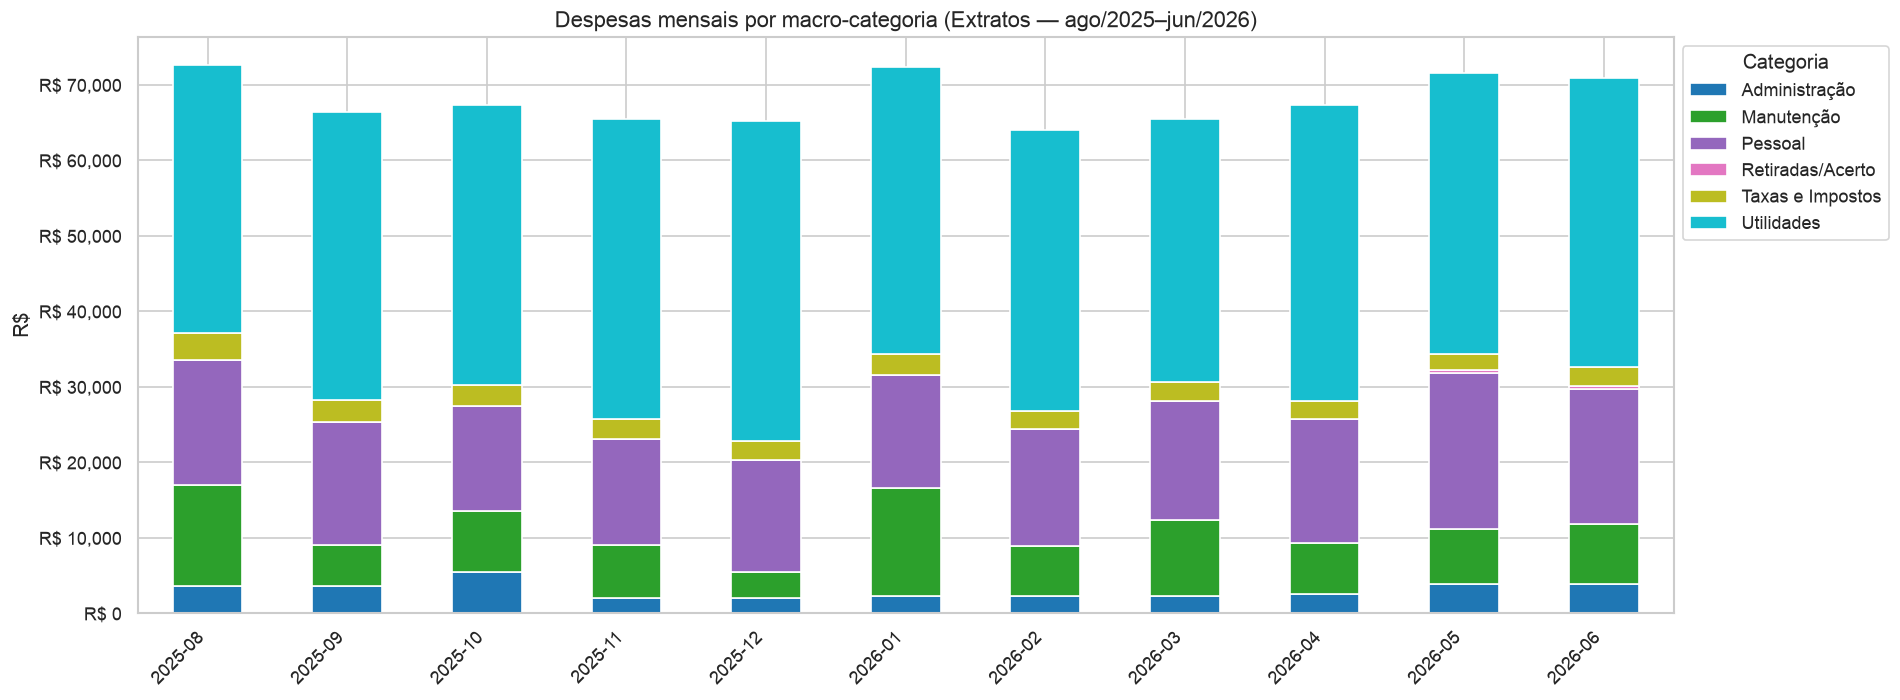

In [5]:
# ── 4.1 Evolução mensal de despesas por macro-categoria ───────────────────
despesas_ext = (
    df_ext[
        (df_ext["subconta"] == "CONTA NORMAL") & df_ext["debito"].notna()
    ]
    .groupby(["mes_ano", "macro_categoria"])["debito"]
    .sum()
    .abs()
    .reset_index()
)

pivot = despesas_ext.pivot(index="mes_ano", columns="macro_categoria", values="debito").fillna(0)

fig, ax = plt.subplots(figsize=(16, 6))
pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Despesas mensais por macro-categoria (Extratos — ago/2025–jun/2026)", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("R$")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), title="Categoria")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

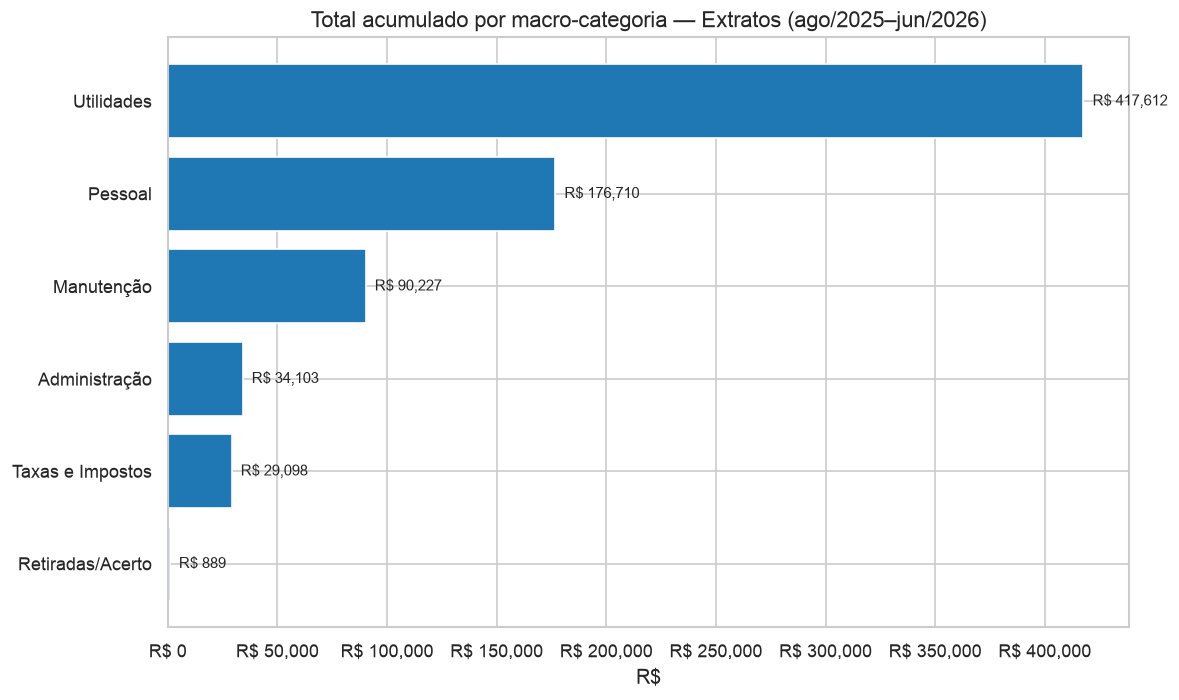

In [6]:
# ── 4.2 Total acumulado por macro-categoria no período ────────────────────
total_por_cat = (
    df_ext[
        (df_ext["subconta"] == "CONTA NORMAL") & df_ext["debito"].notna()
    ]
    .groupby("macro_categoria")["debito"]
    .sum()
    .abs()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(total_por_cat.index, total_por_cat.values)
for bar, val in zip(bars, total_por_cat.values):
    ax.text(bar.get_width() + total_por_cat.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"R$ {val:,.0f}", va="center", fontsize=9)
ax.set_title("Total acumulado por macro-categoria — Extratos (ago/2025–jun/2026)", fontsize=13)
ax.set_xlabel("R$")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
plt.tight_layout()
plt.show()

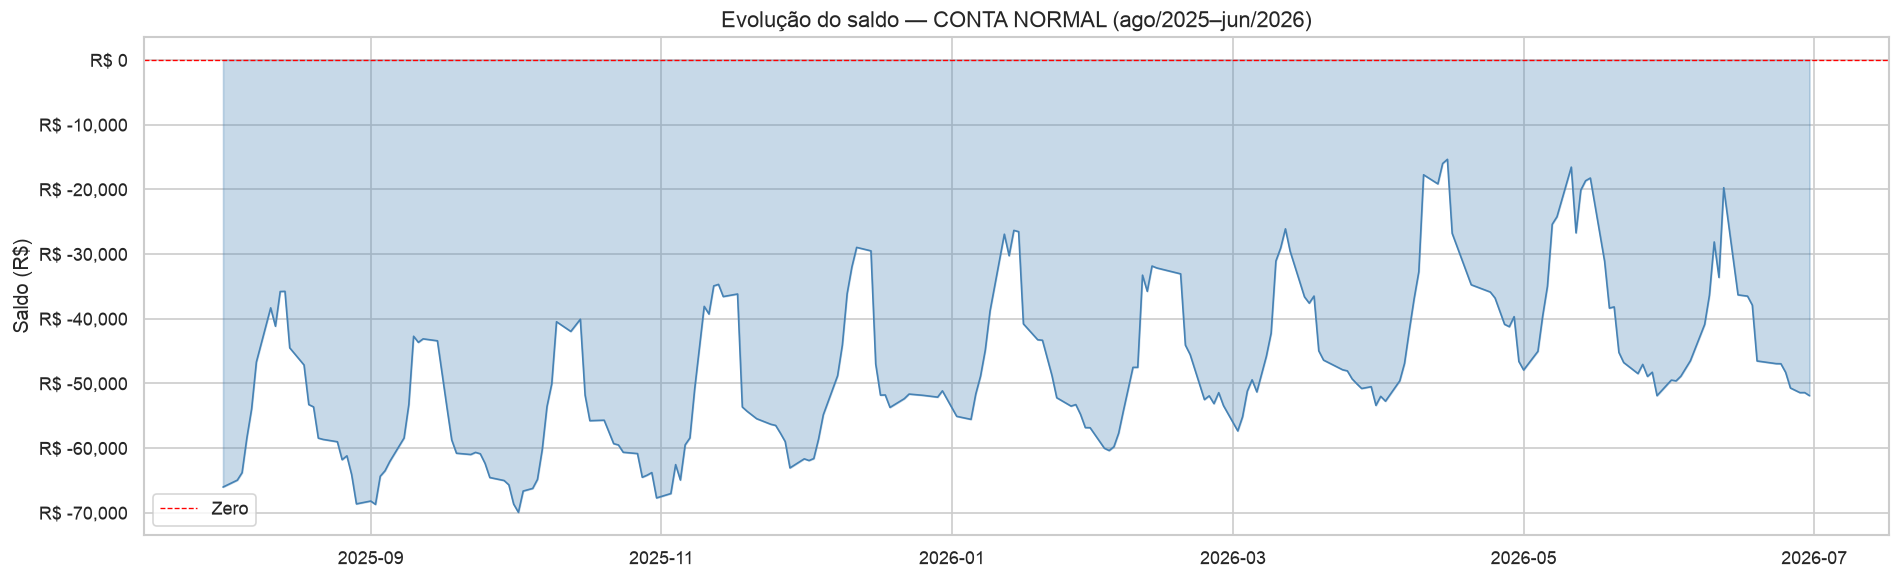

In [7]:
# ── 4.3 Evolução do saldo da CONTA NORMAL ────────────────────────────────
saldo_normal = (
    df_ext[df_ext["subconta"] == "CONTA NORMAL"]
    .sort_values("data")
    .drop_duplicates(subset=["data"], keep="last")
)

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(saldo_normal["data"], saldo_normal["saldo"], alpha=0.3, color="steelblue")
ax.plot(saldo_normal["data"], saldo_normal["saldo"], color="steelblue", linewidth=1)
ax.axhline(0, color="red", linewidth=0.8, linestyle="--", label="Zero")
ax.set_title("Evolução do saldo — CONTA NORMAL (ago/2025–jun/2026)", fontsize=13)
ax.set_ylabel("Saldo (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

## 5. Síndico — Análise Aprofundada (2022–2026)

Análise focada nos gastos com síndico profissional, saques da subconta SAQUES P/ACERTO
e outros pagamentos que merecem atenção especial (honorários, indenizações e e-consignado).

> Os dados de 2022-2023 são carregados de `prestacoes.csv` apenas para comparação.

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.1 Evolução dos pagamentos ao síndico (extratos 2025-2026)
# ═══════════════════════════════════════════════════════════════════════════
sind_ext = df_ext[
    df_ext["historico"].str.upper().str.contains(r"SÍNDICO|SINDICO", na=False)
    & (df_ext["subconta"] == "CONTA NORMAL")
].copy()
sind_ext["valor_abs"] = sind_ext["debito"].abs()

sind_ext["ref_competencia"] = sind_ext["complemento"].str.extract(r"(\d{2}/20\d{2})", expand=False)
sind_ext["tem_nf"] = sind_ext["complemento"].str.upper().str.contains(r"NF\.\d+", na=False)

monthly = sind_ext.groupby("mes_ano").agg(
    n_pagamentos=("valor_abs", "count"),
    total_pago=("valor_abs", "sum"),
    competencias=("ref_competencia", lambda x: ", ".join(x.dropna().tolist())),
    tem_nf=("tem_nf", "all"),
).reset_index()
monthly["⚠️"] = monthly.apply(
    lambda r: "DUPLO" if r["n_pagamentos"] > 1 else ("SEM NF" if not r["tem_nf"] else ""), axis=1
)

print("=== Pagamentos ao síndico (2025-2026) ===")
print(monthly.to_string(index=False))
print(f"\nTotal pago: R$ {sind_ext['valor_abs'].sum():,.2f}")
print(f"Média mensal: R$ {sind_ext['valor_abs'].mean():,.2f}")

sind_prest = df_prest[
    df_prest["evento"].str.upper().str.contains(r"SÍNDICO|SINDICO", na=False)
].copy()
print(f"\n=== Síndico nas prestações (2022-2023) ===")
print(sind_prest[["mes_ano", "evento", "valor"]].to_string(index=False))
print(f"\nMédia mensal 2022-2023: R$ {sind_prest['valor'].mean():,.2f}")
print(f"Variação nominal 2022→2026: {(sind_ext['valor_abs'].mean() / sind_prest['valor'].mean() - 1) * 100:.1f}%")

=== Pagamentos ao síndico (2025-2026) ===
mes_ano  n_pagamentos  total_pago     competencias  tem_nf    ⚠️
2025-08             1      3871.0          07/2025    True      
2025-09             1      3871.0          08/2025    True      
2025-10             1      3871.0          09/2025    True      
2025-11             1      3871.0          10/2025    True      
2025-12             1      3871.0          11/2025    True      
2026-01             1      3871.0          12/2025    True      
2026-02             1      3871.0          01/2026    True      
2026-03             1      3871.0          02/2026    True      
2026-04             1      3871.0          03/2026    True      
2026-05             2      7742.0 04/2026, 05/2026   False DUPLO
2026-06             1      3900.4          06/2026    True      

Total pago: R$ 46,481.40
Média mensal: R$ 3,873.45

=== Síndico nas prestações (2022-2023) ===
mes_ano           evento  valor
2022-05 PG.SÍNDICO PROF. 1750.0
2022-06 PG.SÍNDICO

/var/folders/6n/lp0kv32n54dgmr9xgyd1yg7m0000gn/T/ipykernel_78831/1802425334.py:46: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/chris/Documents/analisis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


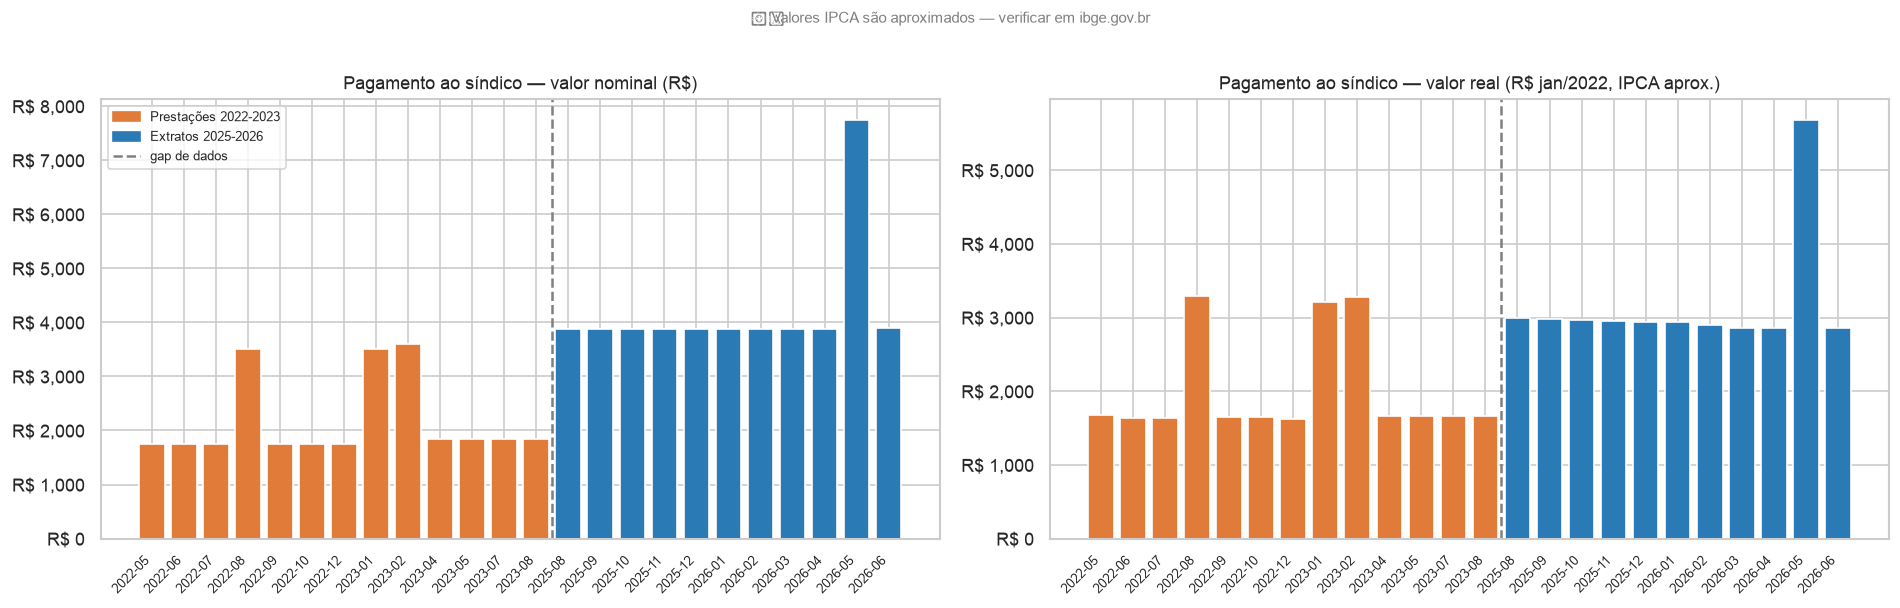


=== Comparação nominal vs real ===
mes_ano  valor_nom   ipca  valor_real_jan22
2022-05     1750.0 1.0473           1670.96
2022-06     1750.0 1.0671           1639.96
2022-07     1750.0 1.0671           1639.96
2022-08     3500.0 1.0633           3291.64
2022-09     1750.0 1.0590           1652.50
2022-10     1750.0 1.0627           1646.75
2022-12     1750.0 1.0809           1619.02
2023-01     3500.0 1.0893           3213.07
2023-02     3600.0 1.0987           3276.60
2023-04     1850.0 1.1112           1664.87
2023-05     1850.0 1.1107           1665.62
2023-07     1850.0 1.1096           1667.27
2023-08     1850.0 1.1127           1662.62
2025-08     3871.0 1.2910           2998.45
2025-09     3871.0 1.2975           2983.43
2025-10     3871.0 1.3048           2966.74
2025-11     3871.0 1.3099           2955.19
2025-12     3871.0 1.3167           2939.93
2026-01     3871.0 1.3188           2935.24
2026-02     3871.0 1.3361           2897.24
2026-03     3871.0 1.3517           2863

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.2 Gráfico nominal vs real (IPCA aprox., base jan/2022)
# ═══════════════════════════════════════════════════════════════════════════
IPCA_BASE_JAN22 = {
    "2022-05": 1.0473, "2022-06": 1.0671, "2022-07": 1.0671,
    "2022-08": 1.0633, "2022-09": 1.0590, "2022-10": 1.0627,
    "2022-11": 1.0692, "2022-12": 1.0809,
    "2023-01": 1.0893, "2023-02": 1.0987, "2023-03": 1.1071,
    "2023-04": 1.1112, "2023-05": 1.1107, "2023-07": 1.1096,
    "2023-08": 1.1127,
    "2025-08": 1.2910, "2025-09": 1.2975, "2025-10": 1.3048,
    "2025-11": 1.3099, "2025-12": 1.3167,
    "2026-01": 1.3188, "2026-02": 1.3361, "2026-03": 1.3517,
    "2026-04": 1.3575, "2026-05": 1.3633, "2026-06": 1.3669,
}

sind_prest_m = sind_prest.groupby("mes_ano")["valor"].sum().reset_index().rename(columns={"valor": "valor_nom"})
sind_ext_m   = sind_ext.groupby("mes_ano")["valor_abs"].sum().reset_index().rename(columns={"valor_abs": "valor_nom"})
sind_hist = pd.concat([sind_prest_m, sind_ext_m], ignore_index=True).sort_values("mes_ano")
sind_hist["ipca"] = sind_hist["mes_ano"].map(IPCA_BASE_JAN22)
sind_hist["valor_real_jan22"] = (sind_hist["valor_nom"] / sind_hist["ipca"]).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cores = ["#e07b39" if m < "2024" else "#2a7ab5" for m in sind_hist["mes_ano"]]

axes[0].bar(range(len(sind_hist)), sind_hist["valor_nom"], color=cores)
axes[0].set_xticks(range(len(sind_hist)))
axes[0].set_xticklabels(sind_hist["mes_ano"], rotation=45, ha="right", fontsize=8)
axes[0].set_title("Pagamento ao síndico — valor nominal (R$)", fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
axes[0].axvline(len(sind_prest_m) - 0.5, color="gray", linestyle="--", linewidth=1.5)
axes[0].legend(handles=[
    Patch(color="#e07b39", label="Prestações 2022-2023"),
    Patch(color="#2a7ab5", label="Extratos 2025-2026"),
    plt.Line2D([0], [0], color="gray", linestyle="--", label="gap de dados"),
], fontsize=8)

axes[1].bar(range(len(sind_hist)), sind_hist["valor_real_jan22"], color=cores)
axes[1].set_xticks(range(len(sind_hist)))
axes[1].set_xticklabels(sind_hist["mes_ano"], rotation=45, ha="right", fontsize=8)
axes[1].set_title("Pagamento ao síndico — valor real (R$ jan/2022, IPCA aprox.)", fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
axes[1].axvline(len(sind_prest_m) - 0.5, color="gray", linestyle="--", linewidth=1.5)

plt.suptitle("⚠️ Valores IPCA são aproximados — verificar em ibge.gov.br", fontsize=9, color="gray", y=1.01)
plt.tight_layout()
plt.show()

print("\n=== Comparação nominal vs real ===")
print(sind_hist[["mes_ano", "valor_nom", "ipca", "valor_real_jan22"]].to_string(index=False))

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.3 Reconciliação mensal: NF vs NF+saques vs NF+saques-devoluções
# ═══════════════════════════════════════════════════════════════════════════
sind_nf = sind_ext.copy()
sind_nf["tem_nf"] = sind_nf["complemento"].str.upper().str.contains(r"NF\.\d+", na=False)
valor_esperado = (
    sind_nf.loc[sind_nf["tem_nf"], "valor_abs"].mode().iloc[0]
    if sind_nf.loc[sind_nf["tem_nf"], "valor_abs"].notna().any()
    else sind_nf["valor_abs"].median()
)

saques_base = df_ext[df_ext["subconta"].eq("SAQUES P/ACERTO")].copy()
saques_base["debito_abs"] = saques_base["debito"].abs()

sind_nf_m = sind_nf.groupby("mes_ano")["valor_abs"].sum()
saques_m  = saques_base.groupby("mes_ano")["debito_abs"].sum()
devol_m   = saques_base.groupby("mes_ano")["credito"].sum()

recon = pd.DataFrame(index=sorted(set(sind_nf_m.index) | set(saques_m.index) | set(devol_m.index)))
recon["nf_apenas"]                  = sind_nf_m.reindex(recon.index).fillna(0.0)
recon["saques"]                     = saques_m.reindex(recon.index).fillna(0.0)
recon["devolucoes"]                 = devol_m.reindex(recon.index).fillna(0.0)
recon["nf_mais_saques"]             = recon["nf_apenas"] + recon["saques"]
recon["nf_mais_saques_menos_devol"] = recon["nf_apenas"] + recon["saques"] - recon["devolucoes"]
recon["delta_nf_vs_esperado"]       = recon["nf_apenas"] - valor_esperado
recon["abaixo_esperado_nf"]         = recon["nf_apenas"] < valor_esperado

print(f"Valor esperado de referência (NF): R$ {valor_esperado:,.2f}\n")
print(recon.reset_index().rename(columns={"index": "mes_ano"}).to_string(index=False))

meses_abaixo = recon[recon["abaixo_esperado_nf"]].index.tolist()
if meses_abaixo:
    print("\nMeses com NF abaixo do esperado:")
    for mm in meses_abaixo:
        print(f"- {mm}: R$ {recon.loc[mm, 'nf_apenas']:,.2f}")
else:
    print("\nNenhum mês com NF abaixo do valor esperado.")

Valor esperado de referência (NF): R$ 3,871.00

mes_ano  nf_apenas  saques  devolucoes  nf_mais_saques  nf_mais_saques_menos_devol  delta_nf_vs_esperado  abaixo_esperado_nf
2025-08     3871.0     0.0         0.0          3871.0                      3871.0                   0.0               False
2025-09     3871.0     0.0         0.0          3871.0                      3871.0                   0.0               False
2025-10     3871.0     0.0         0.0          3871.0                      3871.0                   0.0               False
2025-11     3871.0     0.0         0.0          3871.0                      3871.0                   0.0               False
2025-12     3871.0     0.0         0.0          3871.0                      3871.0                   0.0               False
2026-01     3871.0  1900.0         0.0          5771.0                      5771.0                   0.0               False
2026-02     3871.0  1900.0      1900.0          5771.0                      3

✓ Figura salva: ../exports/figs/sindico_custo_mensal.png


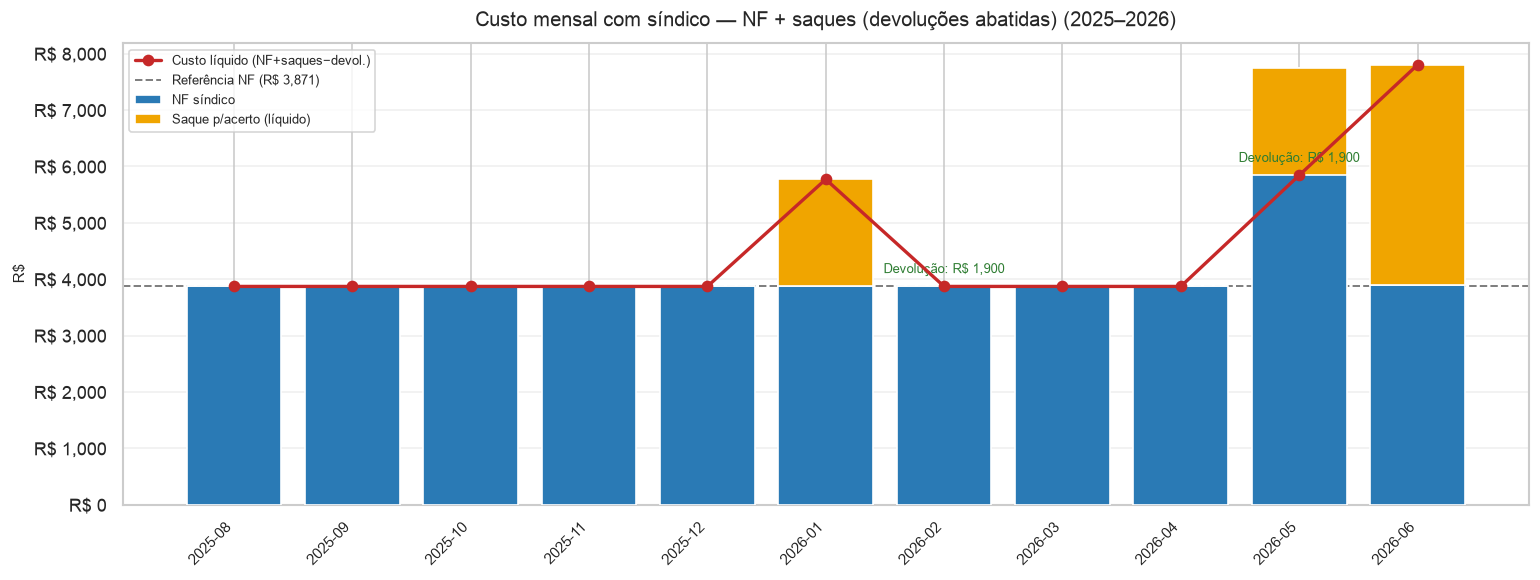

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.3b Gráfico: custo mensal síndico — NF + saques (líquidos, devoluções abatidas)
# ═══════════════════════════════════════════════════════════════════════════
meses = recon.index.tolist()
x = range(len(meses))

# Calcular saques líquidos (saques − devoluções) para que as devoluções sejam abatidas
net_saques = recon["saques"] - recon["devolucoes"]

fig, ax = plt.subplots(figsize=(13, 5))

# Empilhar: NF síndico + Saques líquidos (devoluções já abatidas)
ax.bar(x, recon["nf_apenas"], label="NF síndico", color="#2a7ab5", zorder=3)
ax.bar(x, net_saques, bottom=recon["nf_apenas"], label="Saque p/acerto (líquido)", color="#f0a500", zorder=3)

# Linha do custo líquido (NF + saques − devoluções)
ax.plot(x, recon["nf_mais_saques_menos_devol"], color="#c62828", marker="o", linewidth=2, zorder=4, label="Custo líquido (NF+saques−devol.)")
ax.axhline(valor_esperado, color="gray", linestyle="--", linewidth=1.2, label=f"Referência NF (R$ {valor_esperado:,.0f})")

# Anotar devoluções em cima da barra líquida para referência (sem somar)
for i, m in enumerate(meses):
    dev = recon.loc[m, "devolucoes"]
    if dev > 0:
        ax.annotate(f"Devolução: R$ {dev:,.0f}", xy=(i, recon.loc[m, "nf_mais_saques_menos_devol"]),
                    xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8, color="#2e7d32")

ax.set_xticks(x)
ax.set_xticklabels(meses, rotation=45, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
ax.set_title("Custo mensal com síndico — NF + saques (devoluções abatidas) (2025–2026)", fontsize=12, pad=10)
ax.legend(fontsize=8, loc="upper left")
ax.set_ylabel("R$", fontsize=9)
ax.grid(axis="y", alpha=0.3, zorder=0)
# Salvar figura em PNG na pasta exports/figs
from pathlib import Path
out_dir = Path("../exports/figs")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "sindico_custo_mensal.png"
fig.savefig(out_path, dpi=200)
print(f"✓ Figura salva: {out_path}")
plt.tight_layout()
plt.show()

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.4 Saques p/acerto: ciclo de vida e saldo em aberto
# ═══════════════════════════════════════════════════════════════════════════
mov = saques_base[["data", "mes_ano", "historico", "complemento", "debito_abs", "credito"]].copy()
mov = mov.sort_values("data").reset_index(drop=True)

saques_evt = mov[mov["debito_abs"] > 0].copy().reset_index(drop=True)
devol_evt  = mov[mov["credito"] > 0].copy().reset_index(drop=True)
devol_evt["usado"] = False

linhas = []
for _, s in saques_evt.iterrows():
    candidatos = devol_evt[
        (~devol_evt["usado"]) &
        (devol_evt["data"] >= s["data"]) &
        (devol_evt["credito"].round(2) == round(s["debito_abs"], 2))
    ]
    if candidatos.empty:
        candidatos = devol_evt[(~devol_evt["usado"]) & (devol_evt["data"] >= s["data"])]
    if not candidatos.empty:
        d_idx = candidatos.index[0]
        devol_evt.loc[d_idx, "usado"] = True
        d = devol_evt.loc[d_idx]
        prazo = (d["data"] - s["data"]).days
        status, data_dev, valor_dev = "devolvido", d["data"], float(d["credito"])
    else:
        prazo = None
        status, data_dev, valor_dev = "em_aberto", pd.NaT, 0.0

    linhas.append({
        "data_saque":     s["data"],
        "valor_saque":    float(s["debito_abs"]),
        "data_devolucao": data_dev,
        "valor_devolucao": valor_dev,
        "prazo_dias":     prazo,
        "status":         status,
    })

ciclo_saques = pd.DataFrame(linhas)
saldo_aberto = ciclo_saques.loc[ciclo_saques["status"].eq("em_aberto"), "valor_saque"].sum()

print("=== Ciclo de vida dos saques p/acerto ===")
print(ciclo_saques.to_string(index=False))
print(f"\nSaldo total em aberto: R$ {saldo_aberto:,.2f}")

=== Ciclo de vida dos saques p/acerto ===
data_saque  valor_saque data_devolucao  valor_devolucao  prazo_dias    status
2026-01-16       1900.0     2026-02-04           1900.0        19.0 devolvido
2026-02-24       1900.0     2026-05-21           1900.0        86.0 devolvido
2026-06-17       3900.4            NaT              0.0         NaN em_aberto

Saldo total em aberto: R$ 3,900.40


In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.5 Outros pagamentos relevantes
# ═══════════════════════════════════════════════════════════════════════════
padrao_outros = r"HONOR\.|E-CONSIGNADO|INDENIZ|PG\.ACORDO|PG\.RETIRADA"
outros_rel = df_ext[
    df_ext["historico"].str.upper().str.contains(padrao_outros, regex=True, na=False)
].copy()
# Valor: usar debito quando não-NaN, senão credito (lançamentos de crédito/fundo)
outros_rel["valor"] = outros_rel.apply(
    lambda r: abs(r["debito"]) if pd.notna(r["debito"]) else r["credito"],
    axis=1,
)

if outros_rel.empty:
    print("Nenhum pagamento relevante encontrado.")
else:
    resumo_outros = (
        outros_rel.groupby("historico", as_index=False)
        .agg(
            ocorrencias=("historico", "count"),
            total=("valor", "sum"),
            primeiro_mes=("mes_ano", "min"),
            ultimo_mes=("mes_ano", "max"),
        )
        .sort_values(["total", "ocorrencias"], ascending=False)
    )
    print("=== Resumo ===")
    print(resumo_outros.to_string(index=False))
    print("\n=== Detalhamento ===")
    cols = ["mes_ano", "data", "historico", "complemento", "subconta", "valor"]
    print(outros_rel[cols].sort_values(["data", "historico"]).to_string(index=False))

## 5.6 Acordos — pagamentos e recebimentos (2025–2026)

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.6 Acordos — pagamentos e recebimentos
# ═══════════════════════════════════════════════════════════════════════════
acordos = df_ext[
    df_ext["subconta"].eq("ACORDOS")
    | df_ext["historico"].str.upper().str.contains(r"ACORDO", na=False)
].copy()

# Valor: débito (saída) ou crédito (recebimento de parcela de acordo)
acordos["valor_saida"]   = acordos["debito"].abs()
acordos["valor_entrada"] = acordos["credito"]
acordos["sinal"] = acordos.apply(
    lambda r: "Pagamento" if pd.notna(r["debito"]) else "Recebimento", axis=1
)

print("=== Acordos — todos os lançamentos ===")
cols_ac = ["mes_ano", "data", "subconta", "historico", "complemento", "debito", "credito", "sinal"]
print(acordos[cols_ac].sort_values("data").to_string(index=False))

total_saida   = acordos["valor_saida"].sum()
total_entrada = acordos["valor_entrada"].sum()
print(f"\nTotal saída (pagamentos):     R$ {total_saida:,.2f}")
print(f"Total entrada (recebimentos): R$ {total_entrada:,.2f}")
print(f"Saldo líquido:                R$ {total_entrada - total_saida:,.2f}")

# ── Gráfico mensal ────────────────────────────────────────────────────────
ac_mensal = acordos.groupby("mes_ano").agg(
    saida   =("valor_saida",   "sum"),
    entrada =("valor_entrada", "sum"),
).fillna(0).reset_index()

x_ac = range(len(ac_mensal))
fig_ac, ax_ac = plt.subplots(figsize=(13, 5))
ax_ac.bar(x_ac, ac_mensal["entrada"], label="Recebimentos (crédito)", color="#4caf50", zorder=3)
ax_ac.bar(x_ac, -ac_mensal["saida"],  label="Pagamentos (débito)",    color="#e53935", zorder=3)
ax_ac.axhline(0, color="black", linewidth=0.8)

for i, row in ac_mensal.iterrows():
    if row["saida"] > 0:
        ax_ac.text(i, -row["saida"] - 15, f"R$ {row['saida']:,.0f}",
                   ha="center", va="top", fontsize=8, color="#c62828")
    if row["entrada"] > 0:
        ax_ac.text(i, row["entrada"] + 15, f"R$ {row['entrada']:,.0f}",
                   ha="center", va="bottom", fontsize=8, color="#2e7d32")

ax_ac.set_xticks(x_ac)
ax_ac.set_xticklabels(ac_mensal["mes_ano"], rotation=45, ha="right", fontsize=9)
ax_ac.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {abs(v):,.0f}"))
ax_ac.set_title("Acordos — recebimentos e pagamentos mensais (2025–2026)", fontsize=12, pad=10)
ax_ac.legend(fontsize=9)
ax_ac.set_ylabel("R$ (positivo = entrada, negativo = saída)")
ax_ac.grid(axis="y", alpha=0.3, zorder=0)
plt.tight_layout()
out_ac = out_dir / "acordos_mensal.png"
fig_ac.savefig(out_ac, dpi=200)
print(f"\n✓ Figura salva: {out_ac}")
plt.show()


## 5.7 Portaria e Limpeza — evolução mensal (2025–2026)

=== Portaria + Limpeza por mês ===
         Portaria  Limpeza     Total
mes_ano                             
2025-08  18678.25  5147.30  23825.55
2025-09  18678.25  5147.30  23825.55
2025-10  18678.25  5147.30  23825.55
2025-11  18678.25  5147.30  23825.55
2025-12  18678.25  5147.30  23825.55
2026-01  17674.17  4870.62  22544.79
2026-02  19441.57  5357.68  24799.25
2026-03  19441.57  5357.68  24799.25
2026-04  19441.57  5357.68  24799.25
2026-05  19441.57  5357.68  24799.25
2026-06  19441.57  5357.68  24799.25

Total Portaria: R$ 208,273.27  |  Média: R$ 18,933.93/mês
Total Limpeza:  R$ 57,395.52  |  Média: R$ 5,217.77/mês
Total Combinado: R$ 265,668.79

✓ Figura salva: ../exports/figs/portaria_limpeza_extratos.png


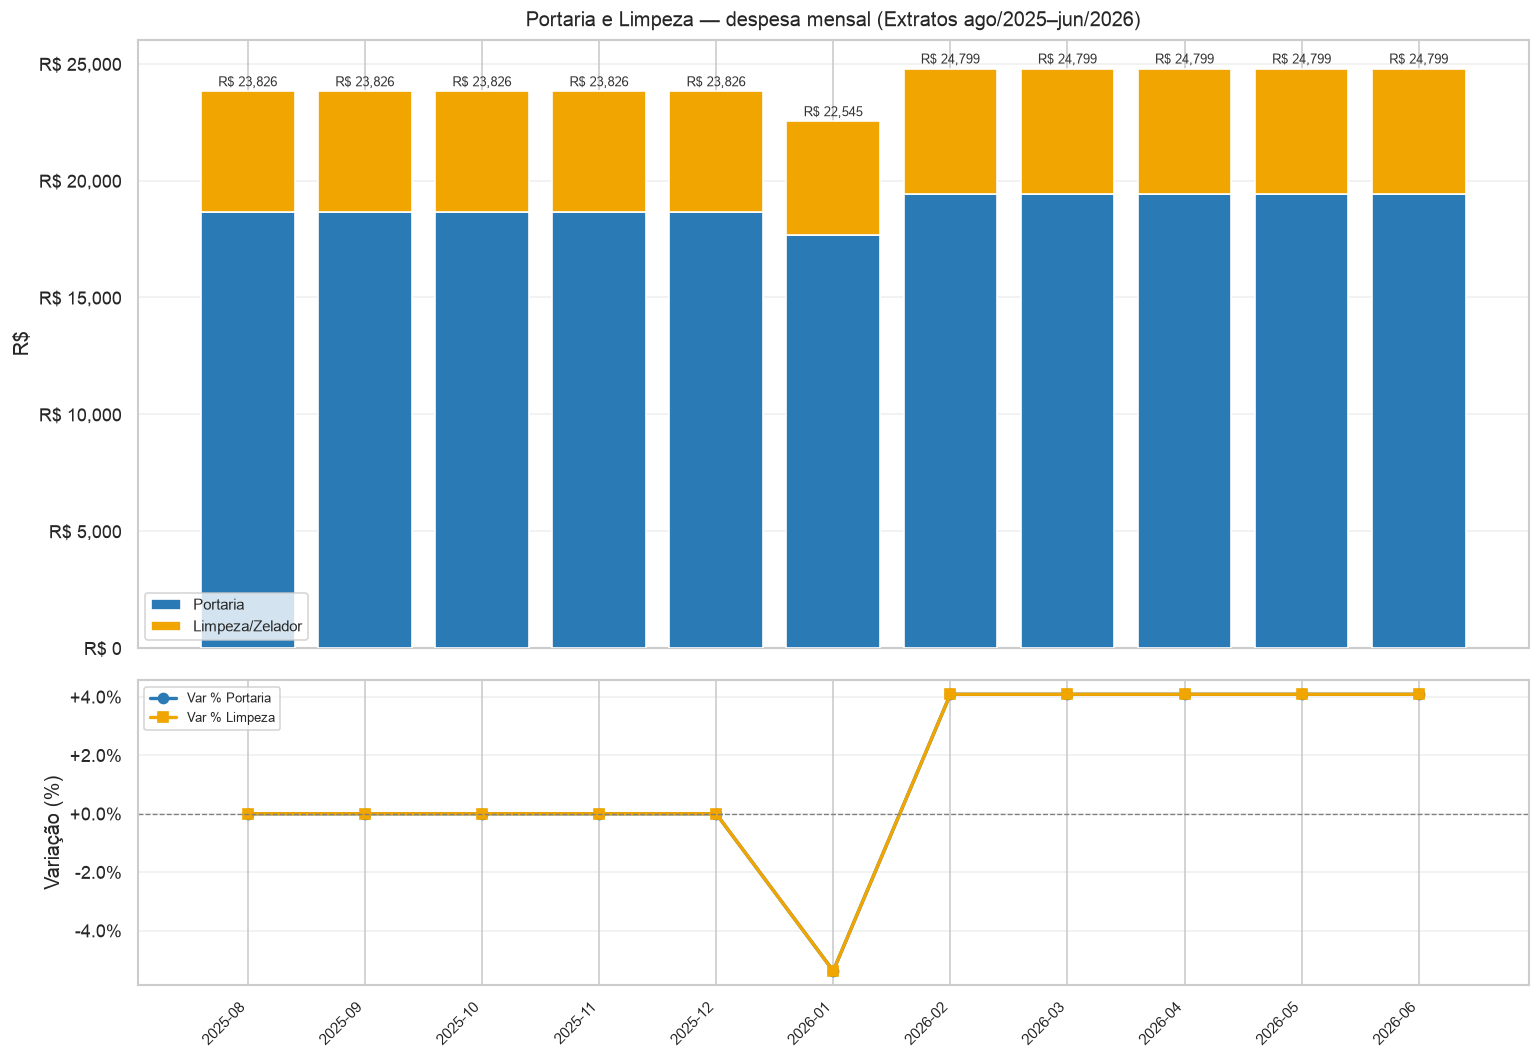

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.7 Portaria e Limpeza — evolução mensal dos contratos de serviço
# ═══════════════════════════════════════════════════════════════════════════
FILTRO_PORTARIA = "PG.SERV.PORTARIA"
FILTRO_LIMPEZA  = "PG.SERV.LIMP."

port_df = df_ext[
    df_ext["historico"].str.upper().str.contains(FILTRO_PORTARIA, na=False)
    & (df_ext["subconta"] == "CONTA NORMAL")
].copy()

limp_df = df_ext[
    df_ext["historico"].str.upper().str.contains(FILTRO_LIMPEZA, na=False)
    & (df_ext["subconta"] == "CONTA NORMAL")
].copy()

port_m = port_df.groupby("mes_ano")["debito"].sum().abs()
limp_m = limp_df.groupby("mes_ano")["debito"].sum().abs()

# Combinar em DataFrame único alinhando por mes_ano
pl = pd.DataFrame({
    "Portaria": port_m,
    "Limpeza":  limp_m,
}).fillna(0)
pl["Total"] = pl["Portaria"] + pl["Limpeza"]

print("=== Portaria + Limpeza por mês ===")
print(pl.to_string())
print(f"\nTotal Portaria: R$ {pl['Portaria'].sum():,.2f}  |  Média: R$ {pl[pl['Portaria']>0]['Portaria'].mean():,.2f}/mês")
print(f"Total Limpeza:  R$ {pl['Limpeza'].sum():,.2f}  |  Média: R$ {pl[pl['Limpeza']>0]['Limpeza'].mean():,.2f}/mês")
print(f"Total Combinado: R$ {pl['Total'].sum():,.2f}")

# ── Gráfico: barras empilhadas + variação % ───────────────────────────────
base_mes = pl[pl["Total"] > 0].index[0]
base_port = pl.loc[base_mes, "Portaria"]
base_limp = pl.loc[base_mes, "Limpeza"] if pl.loc[base_mes, "Limpeza"] > 0 else None

fig_pl, (ax_bar, ax_var) = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                                         gridspec_kw={"height_ratios": [3, 1.5]})

x_pl = range(len(pl))
ax_bar.bar(x_pl, pl["Portaria"], label="Portaria", color="#2a7ab5", zorder=3)
ax_bar.bar(x_pl, pl["Limpeza"], bottom=pl["Portaria"], label="Limpeza/Zelador", color="#f0a500", zorder=3)

for xi, (_, row) in zip(x_pl, pl.iterrows()):
    if row["Total"] > 0:
        ax_bar.text(xi, row["Total"] + 100, f"R$ {row['Total']:,.0f}",
                    ha="center", va="bottom", fontsize=7.5, color="#333")

ax_bar.set_ylabel("R$")
ax_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
ax_bar.legend(fontsize=9)
ax_bar.set_title("Portaria e Limpeza — despesa mensal (Extratos ago/2025–jun/2026)", fontsize=12, pad=8)
ax_bar.grid(axis="y", alpha=0.3, zorder=0)

# Variação % em relação ao 1º mês com dados
var_port = ((pl["Portaria"] / base_port - 1) * 100).where(pl["Portaria"] > 0)
ax_var.plot(x_pl, var_port, color="#2a7ab5", marker="o", linewidth=2, label="Var % Portaria")
if base_limp:
    var_limp = ((pl["Limpeza"] / base_limp - 1) * 100).where(pl["Limpeza"] > 0)
    ax_var.plot(x_pl, var_limp, color="#f0a500", marker="s", linewidth=2, label="Var % Limpeza")
ax_var.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax_var.set_ylabel("Variação (%)")
ax_var.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.1f}%"))
ax_var.legend(fontsize=8)
ax_var.grid(axis="y", alpha=0.3)

plt.xticks(ticks=x_pl, labels=pl.index, rotation=45, ha="right", fontsize=9)
plt.tight_layout()
out_pl = out_dir / "portaria_limpeza_extratos.png"
fig_pl.savefig(out_pl, dpi=200)
print(f"\n✓ Figura salva: {out_pl}")
plt.show()


## 6. Exportar dados normalizados e anomalias

## 5.8 Alojamento/Depósito — evolução mensal (2025–2026)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.8 Alojamento/Depósito — evolução mensal dos recebimentos
# ═══════════════════════════════════════════════════════════════════════════
FILTRO_ALOJAMENTO = r"ALUG\.DEPÓSITO|ALUG\.DEPOSITO|REC\.ALUG|USO BOX|USO.BOX"

aloj_df = df_ext[
    (df_ext["historico"].str.upper().str.contains(FILTRO_ALOJAMENTO, na=False, regex=True))
    | (df_ext["subconta"] == "USO DO BOX")
].copy()

aloj_m = aloj_df.groupby("mes_ano").agg(
    total_receita=("credito", "sum"),
    n_lançamentos=("historico", "count"),
    tipos=("historico", lambda x: ", ".join(x.unique().tolist())),
).reset_index()

print("=== Alojamento/Depósito — receita mensal ===")
print(aloj_m.to_string(index=False))
print(f"\nTotal recebido: R$ {aloj_df['credito'].sum():,.2f}")
print(f"Média mensal: R$ {aloj_m['total_receita'].mean():,.2f}")

# ── Gráfico: barras + variação % ───────────────────────────────────────────
if len(aloj_m) > 0:
    fig_aloj, (ax_bar, ax_var) = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                                               gridspec_kw={"height_ratios": [3, 1.5]})
    
    x_aloj = range(len(aloj_m))
    ax_bar.bar(x_aloj, aloj_m["total_receita"], color="#66bb6a", zorder=3, width=0.6)
    
    for xi, (_, row) in zip(x_aloj, aloj_m.iterrows()):
        if row["total_receita"] > 0:
            ax_bar.text(xi, row["total_receita"] + 20, f"R$ {row['total_receita']:,.0f}",
                       ha="center", va="bottom", fontsize=8, color="#1b5e20")
    
    ax_bar.set_ylabel("R$")
    ax_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
    ax_bar.set_title("Alojamento/Depósito — receita mensal (2025–2026)", fontsize=12, pad=8)
    ax_bar.grid(axis="y", alpha=0.3, zorder=0)
    
    # Variação % em relação ao 1º mês com dados
    primeira_receita = aloj_m[aloj_m["total_receita"] > 0]["total_receita"].iloc[0]
    var_aloj = ((aloj_m["total_receita"] / primeira_receita - 1) * 100).where(aloj_m["total_receita"] > 0)
    ax_var.plot(x_aloj, var_aloj, color="#66bb6a", marker="o", linewidth=2, markersize=6)
    ax_var.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax_var.set_ylabel("Variação (%)")
    ax_var.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.1f}%"))
    ax_var.grid(axis="y", alpha=0.3)
    
    plt.xticks(ticks=x_aloj, labels=aloj_m["mes_ano"], rotation=45, ha="right", fontsize=9)
    plt.tight_layout()
    out_aloj = out_dir / "alojamento_evolucao.png"
    fig_aloj.savefig(out_aloj, dpi=200)
    print(f"\n✓ Figura salva: {out_aloj}")
    plt.show()
else:
    print("\n⚠️ Nenhum lançamento de alojamento encontrado no período.")

In [19]:
df_ext.to_csv(CSV_DIR / "lancamentos_normalizados.csv", index=False)
print(f"✓ lancamentos_normalizados.csv — {len(df_ext):,} registros")

df_anomalias.to_csv(CSV_DIR / "anomalias.csv", index=False)
print(f"✓ anomalias.csv              — {len(df_anomalias):,} registros")

print("\n=== Arquivos em exports/csv/ ===")
for f in sorted(CSV_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<40} {size_kb:6.1f} KB")

✓ lancamentos_normalizados.csv — 6,215 registros
✓ anomalias.csv              — 307 registros

=== Arquivos em exports/csv/ ===
  anomalias.csv                              42.2 KB
  extratos.csv                              578.0 KB
  lancamentos_normalizados.csv              652.3 KB
  prestacoes.csv                             36.5 KB
